In [30]:
from pathlib import Path
import json, sqlite3, math
import pandas as pd
import plotly.express as px
from IPython.display import display

# Nur diesen Pfad anpassen:
#ROOT = Path("/home/jonas/SynologyDrive/Uni-MA/2026_SoSe/Praktikum/results-sketches")
ROOT = Path("/home/jonas/SynologyDrive/Uni-MA/2026_SoSe/Praktikum/new-results")

NEW_BASE_FOR_IMAGES="/home/jonas/Datasets/TikZ/normal/benchmark/simple_llm_description/images"

# Auswahl für die Manifest-Dateien:
MODEL = "gemma4-31b-it-q4_K_M-normal"
METRICS = [
    "siglip_similarity",
    "lpips_similarity",
    "dreamsim_similarity",
]

N = 50


def as_json(value):
    if isinstance(value, dict):
        return value
    try:
        return json.loads(value or "{}")
    except (TypeError, json.JSONDecodeError):
        return {}


dbs = [ROOT] if ROOT.is_file() else sorted(ROOT.rglob("promptfoo-db/promptfoo.db"))
if not dbs:
    raise FileNotFoundError(f"Keine promptfoo.db unter {ROOT} gefunden.")

rows, metrics = [], set()

for db in dbs:
    model = db.parents[1].name
    with sqlite3.connect(db) as con:
        data = pd.read_sql_query(
            "SELECT id, test_case, named_scores, response FROM eval_results", con
        )

    for row in data.itertuples(index=False):
        variables = as_json(row.test_case).get("vars", {})
        scores = as_json(row.named_scores)
        metrics.update(scores)
        response = as_json(row.response)
        generated_code = response.get("output")
        if not isinstance(generated_code, str):
            generated_code = as_json(response.get("raw")).get("output", "")

        rows.append({
            "model": model,
            "id": row.id,
            "generated_code": generated_code,
            **variables,
            **scores,
        })

df = pd.DataFrame(rows)
metrics = sorted(metrics)

for metric in metrics:
    df[metric] = pd.to_numeric(df[metric], errors="coerce")

print("Modelle:", *sorted(df["model"].unique()), sep="\n- ")
print("\nMetriken:", *metrics, sep="\n- ")

Modelle:
- detikzify-2-5-8b-normal
- detikzify-2-5-8b-replacement
- gemma4-12b-it-bf16-normal
- gemma4-31b-it-q4_K_M-descr
- gemma4-31b-it-q4_K_M-normal
- geotikzbridge-8b-normal
- qwen3-vl-8b-instruct-bf16-descr
- qwen3-vl-8b-instruct-bf16-normal
- qwen3.6-35b-a3b-normal

Metriken:
- clip_similarity
- crystalbleu
- dists_distance
- dists_similarity
- dreamsim_similarity
- image_ms_ssim
- image_ssim
- latex_badboxes
- latex_errors
- latex_warnings
- lpips_distance
- lpips_similarity
- output_length
- reference_length
- relative_length_similarity
- renderable
- siglip_similarity
- ted_distance
- ted_similarity
- thinking_length


In [31]:
# Durchschnitt je Metrik und Modell
means = df.groupby("model")[metrics].mean().T

def mark_min_max(row):
    style = pd.Series("", index=row.index)
    values = row.dropna()
    if values.empty:
        return style
    style[row.eq(values.max())] = "background:#d9ead3;color:#245b3a;font-weight:bold"
    if values.min() != values.max():
        style[row.eq(values.min())] = "background:#f4cccc;color:#8b2d2d;font-weight:bold"
    return style

display(
    means.style
         .format("{:.3f}")
         .apply(mark_min_max, axis=1)
         .set_caption("Durchschnittliche Metrikwerte je Modell – Minimum rot, Maximum grün")
)

model,detikzify-2-5-8b-normal,detikzify-2-5-8b-replacement,gemma4-12b-it-bf16-normal,gemma4-31b-it-q4_K_M-descr,gemma4-31b-it-q4_K_M-normal,geotikzbridge-8b-normal,qwen3-vl-8b-instruct-bf16-descr,qwen3-vl-8b-instruct-bf16-normal,qwen3.6-35b-a3b-normal
clip_similarity,0.953,0.936,0.875,0.896,0.900,0.869,0.888,0.825,0.870
crystalbleu,0.140,0.125,0.126,0.260,0.141,0.128,0.316,0.137,0.146
dists_distance,0.165,0.184,0.262,0.208,0.227,0.222,0.231,0.256,0.246
dists_similarity,0.860,0.847,0.771,0.800,0.797,0.791,0.799,0.729,0.770
dreamsim_similarity,0.900,0.874,0.757,0.826,0.813,0.772,0.786,0.710,0.763
image_ms_ssim,0.658,0.641,0.578,0.593,0.583,0.621,0.591,0.525,0.563
image_ssim,0.811,0.806,0.776,0.772,0.780,0.775,0.783,0.724,0.759
latex_badboxes,0.192,0.162,0.010,0.394,0.020,0.227,0.320,0.230,0.354
latex_errors,0.084,0.072,5.349,3.700,5.196,4.305,4.648,4.150,3.792
latex_warnings,0.512,0.456,0.380,0.232,0.070,0.932,0.348,0.102,0.382


In [32]:
# Verteilungen: Boxplot + alle Einzelwerte
long = df.melt(
    id_vars="model",
    value_vars=metrics,
    var_name="metric",
    value_name="value",
).dropna()

fig = px.box(
    long,
    x="model",
    y="value",
    color="model",
    facet_col="metric",
    facet_col_wrap=4,
    points="all",
    height=280 * math.ceil(len(metrics) / 4),
    title="Promptfoo Score Metrics by Model",
)
fig.update_layout(showlegend=False)
fig.update_yaxes(matches=None)
fig.update_xaxes(tickangle=25)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

In [33]:
# Gemeinsamen Score berechnen und zwei manifest.csv erzeugen
missing = [metric for metric in METRICS if metric not in metrics]
if missing:
    raise ValueError(f"Unbekannte Metriken: {missing}")
if MODEL not in set(df["model"]):
    raise ValueError(f"Unbekanntes Modell: {MODEL}")

selected = df[df["model"].eq(MODEL)].dropna(subset=METRICS).copy()

def lower_is_better(metric):
    return (
        metric.endswith("_distance")
        or metric in {"latex_errors", "latex_warnings", "latex_badboxes"}
    )

normalized = []

for metric in METRICS:
    values = selected[metric]
    minimum, maximum = values.min(), values.max()

    if maximum == minimum:
        score = pd.Series(1.0, index=selected.index)
    else:
        score = (values - minimum) / (maximum - minimum)

    if lower_is_better(metric):
        score = 1 - score

    normalized.append(score)

selected["combined_score"] = pd.concat(normalized, axis=1).mean(axis=1)

best = selected.nlargest(N, "combined_score")
worst = selected.nsmallest(N, "combined_score")

columns = {
    "reference_image": "image_path",
    "input_image": "input_image_path",
    "reference_code": "code_path",
    "llm_description": "vlm_description_path",
}

metric_name = "__".join(METRICS)
base = ROOT if ROOT.is_dir() else ROOT.parents[2]
out = base / "manifests" / MODEL / metric_name

best_path = out / "best" / "manifest.csv"
worst_path = out / "worst" / "manifest.csv"
best_path.parent.mkdir(parents=True, exist_ok=True)
worst_path.parent.mkdir(parents=True, exist_ok=True)

try:
    best[list(columns)].rename(columns=columns).to_csv(best_path, index=False)
    worst[list(columns)].rename(columns=columns).to_csv(worst_path, index=False)
except KeyError:
    columns = {
    "reference_image": "image_path",
    "reference_code": "code_path",
    "llm_description": "vlm_description_path",
    }
    
    best[list(columns)].rename(columns=columns).to_csv(best_path, index=False)
    worst[list(columns)].rename(columns=columns).to_csv(worst_path, index=False)

    best["input_image"] = best["reference_image"]
    worst["input_image"] = worst["reference_image"]


display(
    selected[["combined_score", *METRICS]]
    .sort_values("combined_score", ascending=False)
    .head(N)
)

print(best_path)
print(worst_path)

,combined_score,siglip_similarity,lpips_similarity,dreamsim_similarity
2123,0.992088,0.982315,0.962442,0.985093
2422,0.989586,0.983485,0.954225,0.984820
2140,0.982313,0.984681,0.934386,0.982139
2058,0.973947,0.978350,0.937923,0.960142
2020,0.970972,0.966518,0.936374,0.964674
2027,0.966911,0.972442,0.909402,0.973978
2350,0.962365,0.965299,0.966465,0.910111
2275,0.959975,0.921878,0.977087,0.935503
2476,0.954097,0.962415,0.927993,0.927331
2249,0.953820,0.990072,0.892819,0.934484


/home/jonas/SynologyDrive/Uni-MA/2026_SoSe/Praktikum/new-results/manifests/gemma4-31b-it-q4_K_M-normal/siglip_similarity__lpips_similarity__dreamsim_similarity/best/manifest.csv
/home/jonas/SynologyDrive/Uni-MA/2026_SoSe/Praktikum/new-results/manifests/gemma4-31b-it-q4_K_M-normal/siglip_similarity__lpips_similarity__dreamsim_similarity/worst/manifest.csv


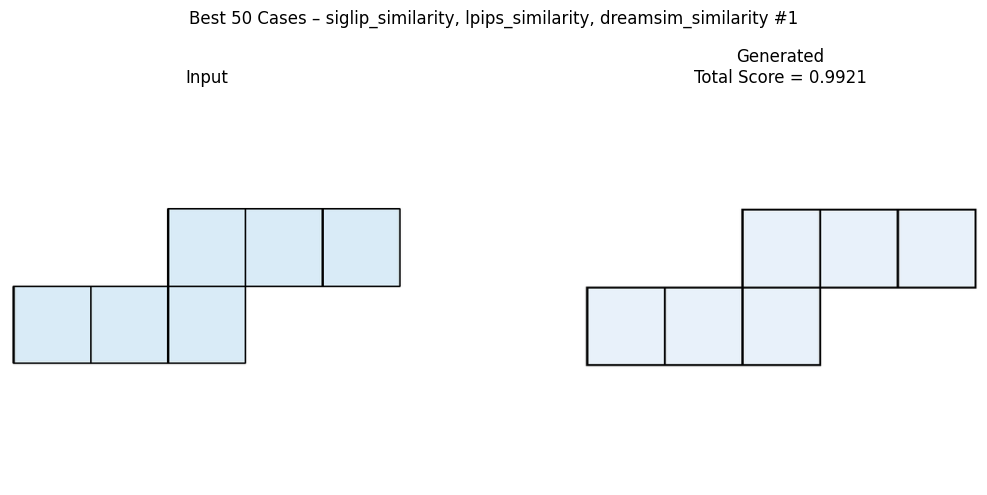

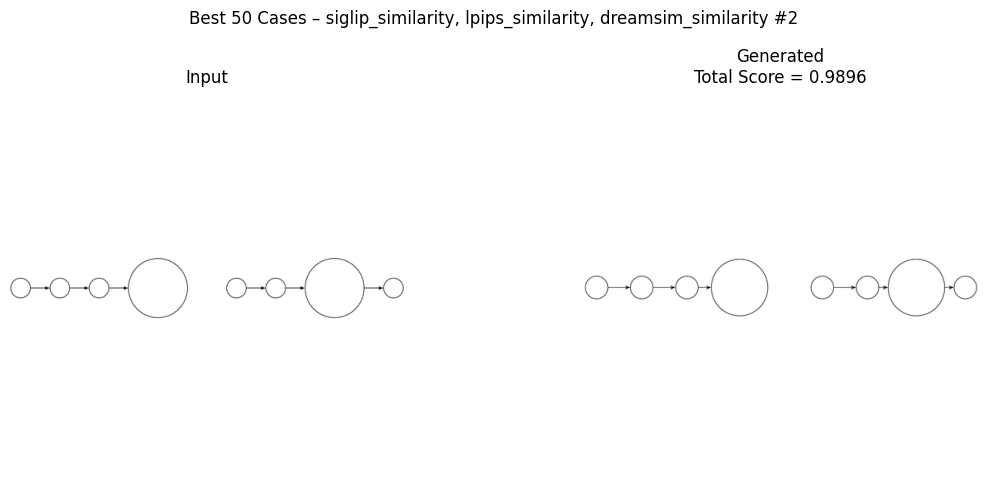

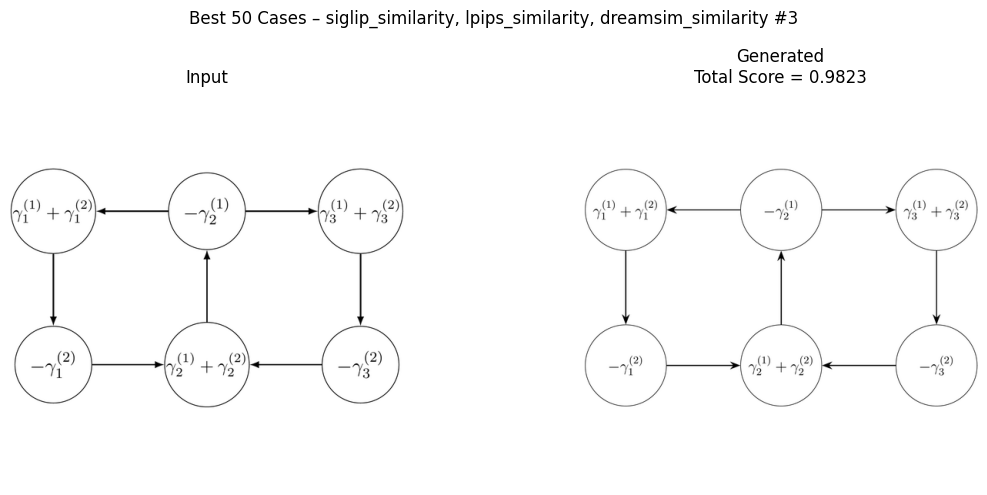

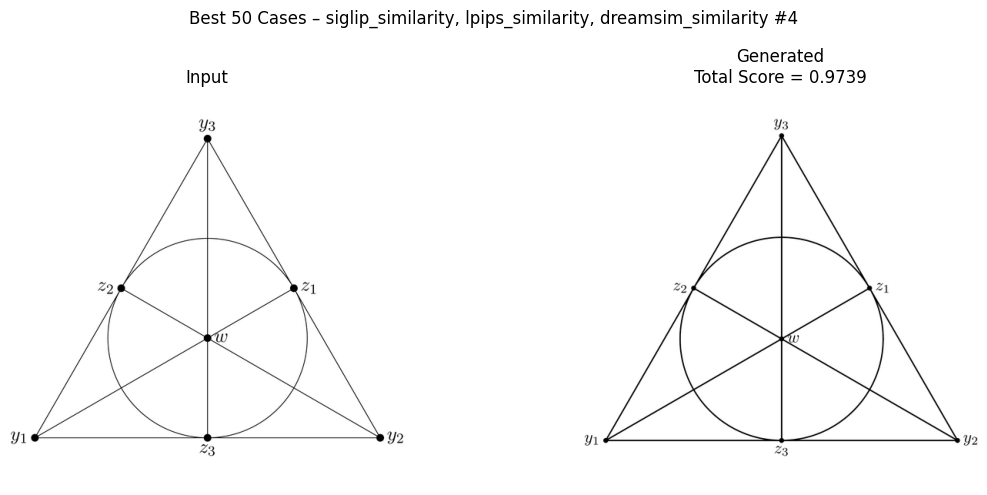

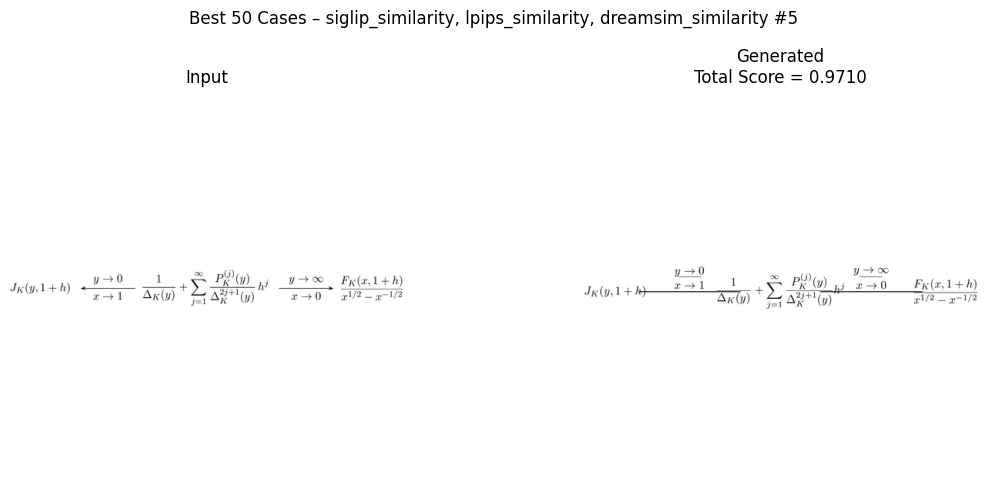

...

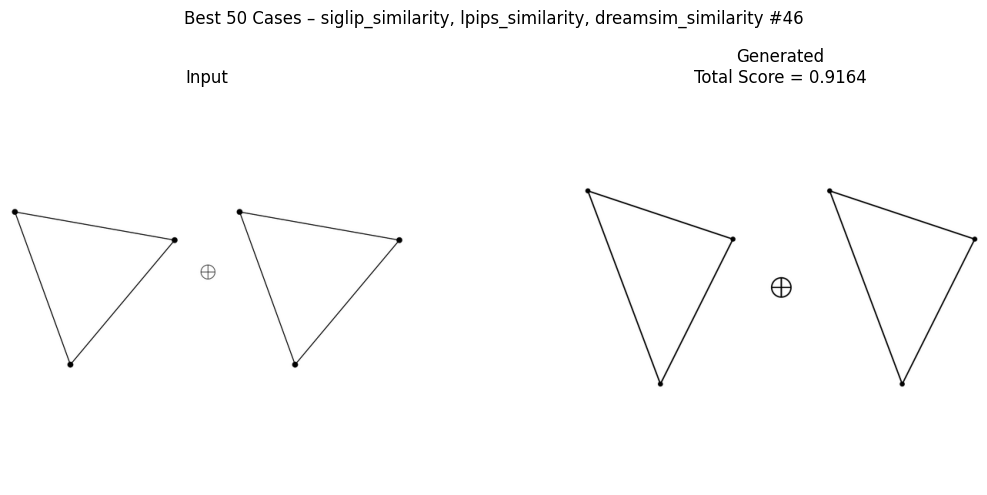

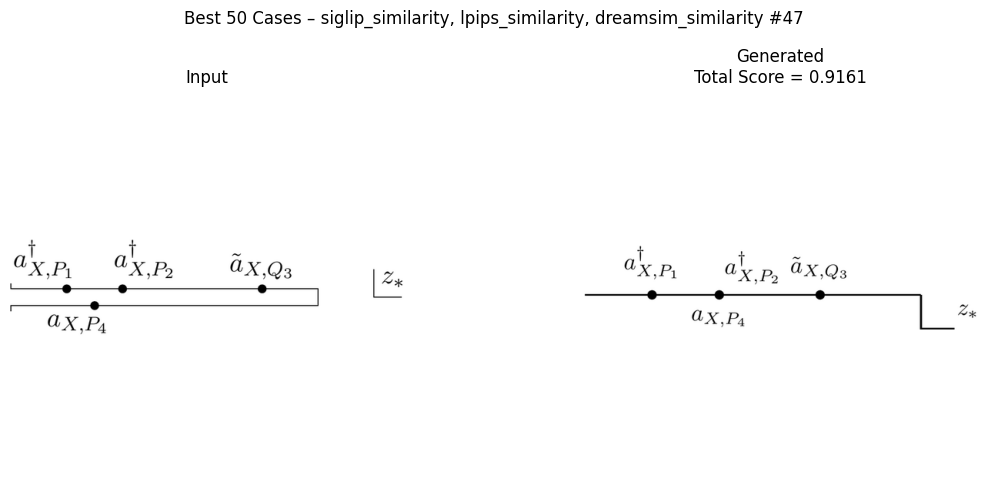

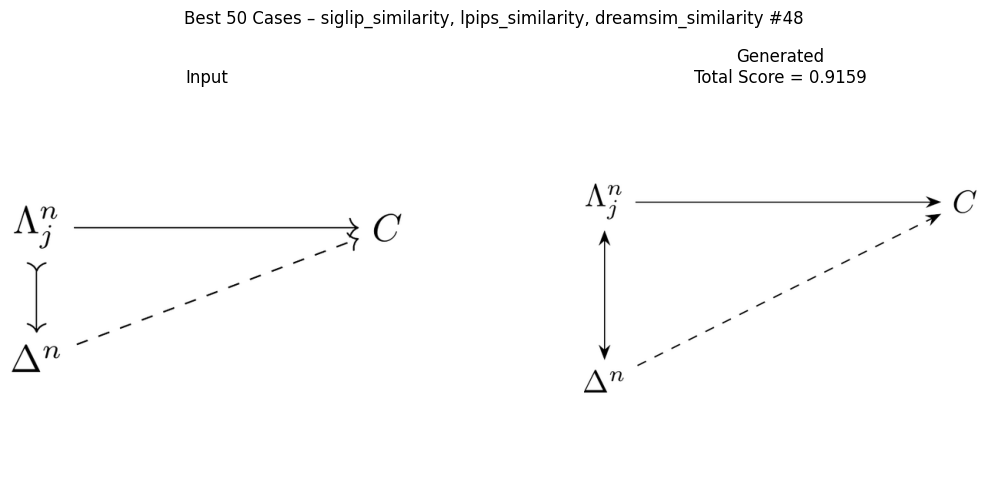

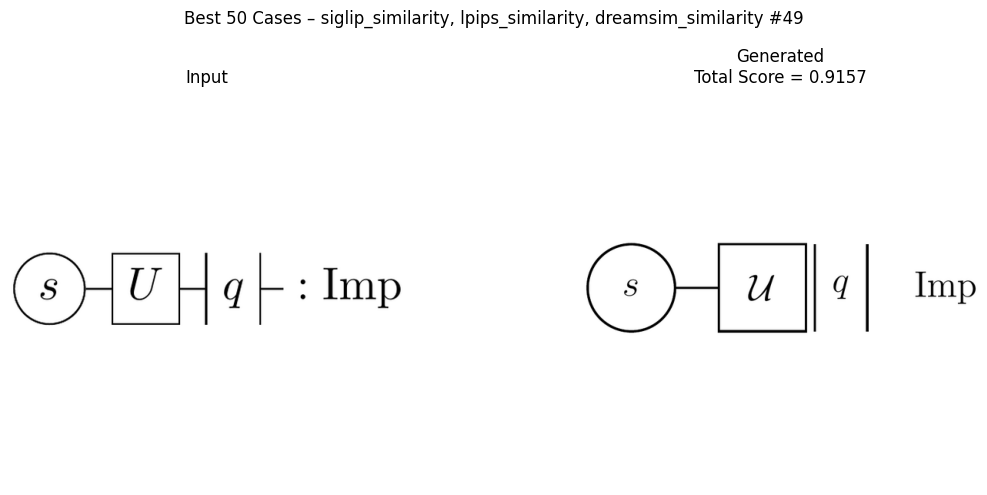

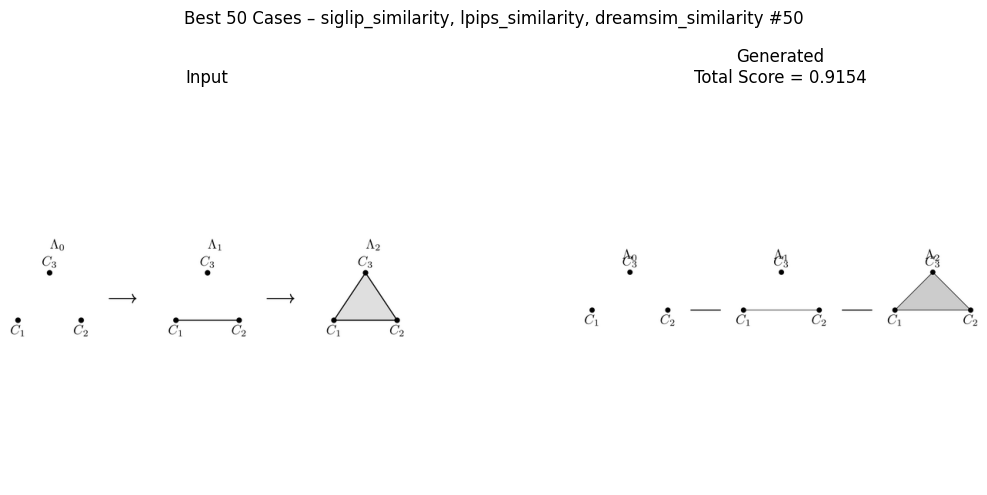

In [34]:
# Beste Fälle: vorhandenes generiertes Bild und Input-Bild anzeigen
import matplotlib.pyplot as plt
from PIL import Image


def generated_image_path(row):
    folder = ROOT / MODEL / "generated_images"

    # Standard: <input-stem>_generated.png
    candidates = [
        folder / f"{Path(row['input_image']).stem}_generated.png",
        folder / f"{Path(row['reference_image']).stem}_generated.png",
    ]

    for path in candidates:
        if path.exists():
            return path

    # Fallback: Suche nach passendem Namen
    stems = {
        Path(row["input_image"]).stem,
        Path(row["reference_image"]).stem,
    }
    for stem in stems:
        matches = sorted(folder.glob(f"{stem}*_generated.*"))
        if matches:
            return matches[0]

    return candidates[0]


def show_cases(cases, heading):
    for rank, (_, row) in enumerate(cases.iterrows(), 1):
        generated_path = generated_image_path(row)
        input_path = Path(row["input_image"])

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        try:
            if input_path.exists():
                with Image.open(input_path) as image:
                    axes[0].imshow(image.convert("RGB"))
            else:
                with Image.open(f"{NEW_BASE_FOR_IMAGES}/{Path(input_path).name}") as image:
                    axes[0].imshow(image.convert("RGB"))
        except PermissionError:
            with Image.open(f"{NEW_BASE_FOR_IMAGES}/{Path(input_path).name}") as image:
                axes[0].imshow(image.convert("RGB"))
            
        if generated_path.exists():
            with Image.open(generated_path) as image:
                axes[1].imshow(image.convert("RGB"))
        else:
            axes[1].text(
                0.5, 0.5,
                f"No image generated",
                ha="center", va="center"
            )

        axes[0].set_title("Input")
        axes[1].set_title(
            f"Generated\nTotal Score = {row['combined_score']:.4f}"
        )
        fig.suptitle(f"{heading} #{rank}")

        for axis in axes:
            axis.axis("off")

        plt.tight_layout()
        plt.show()


show_cases(best, f"Best {len(best)} Cases – " + ", ".join(METRICS))

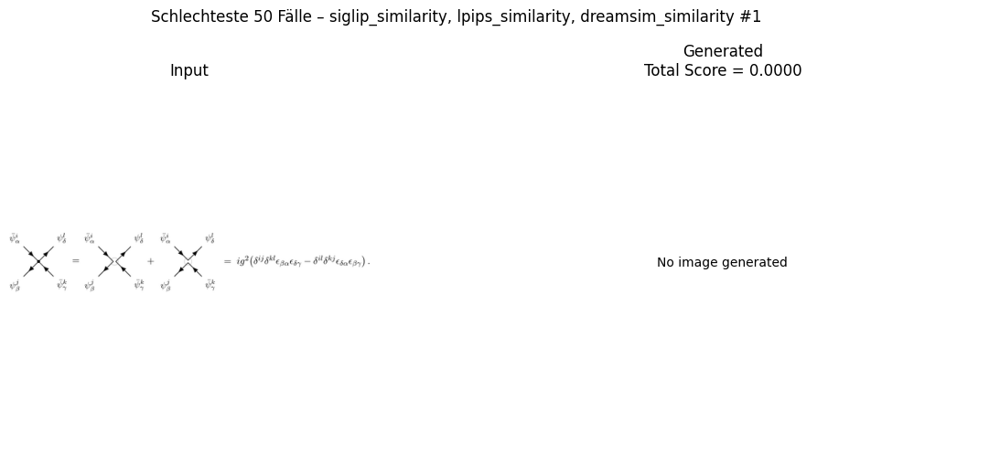

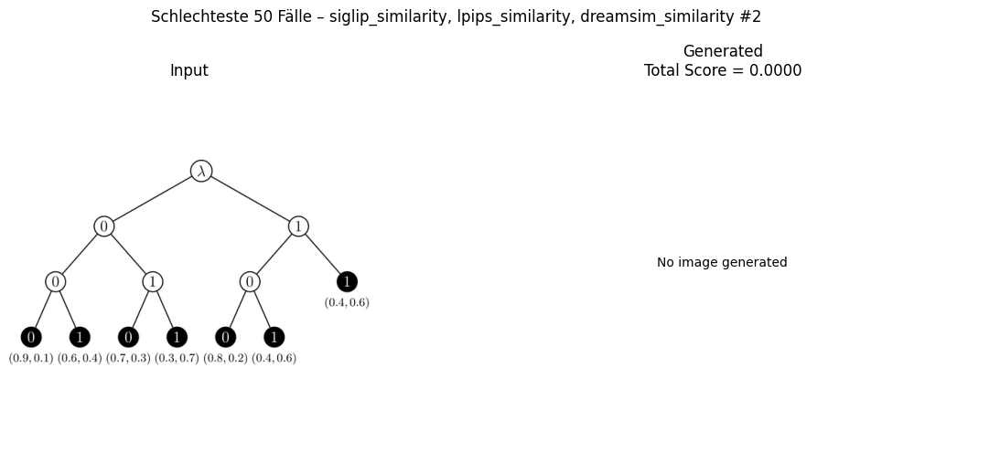

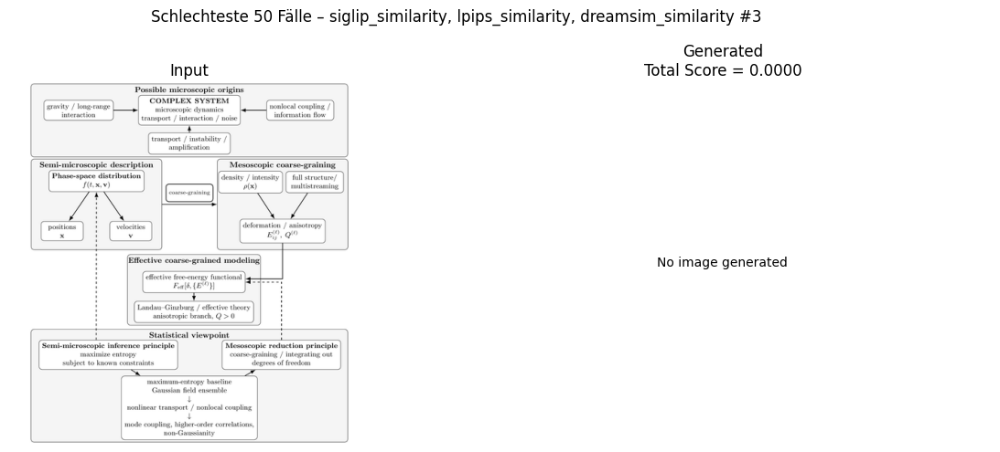

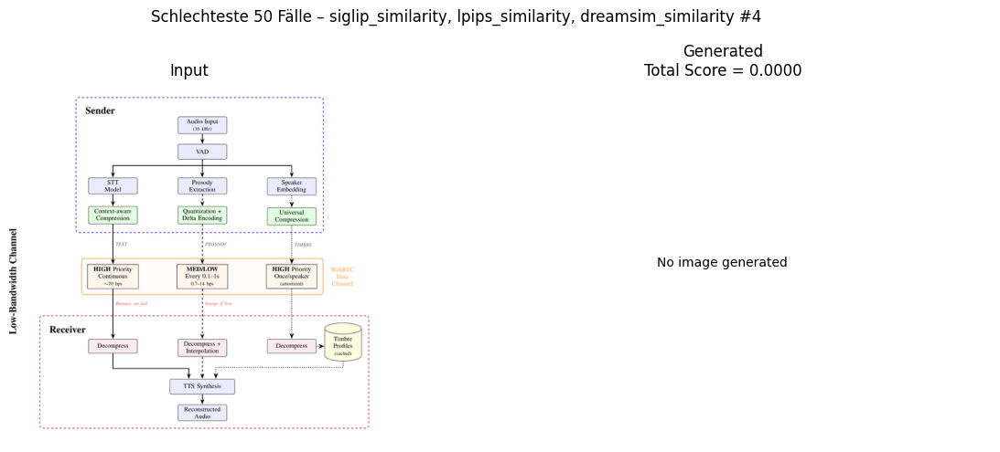

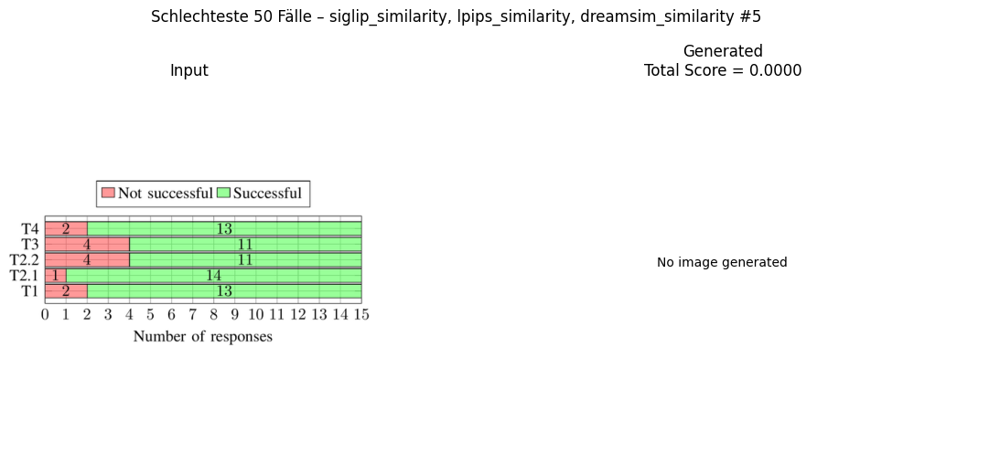

...

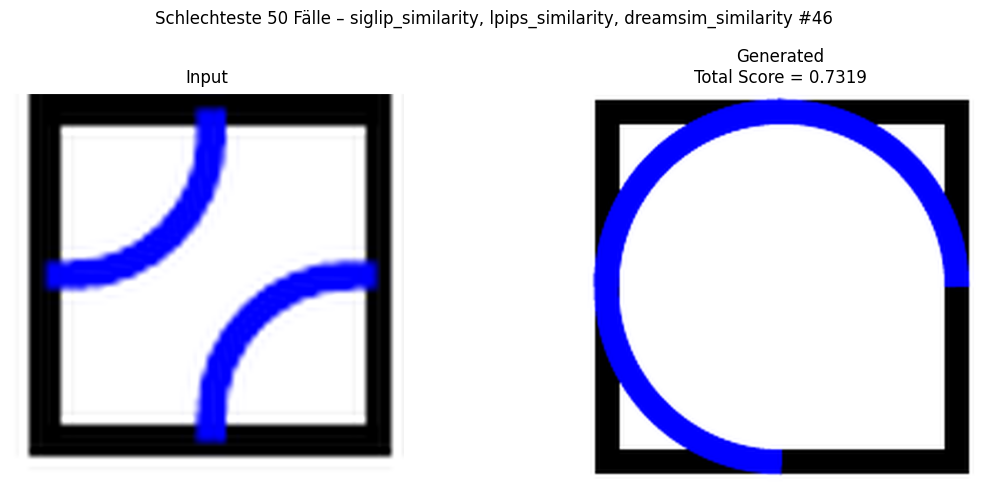

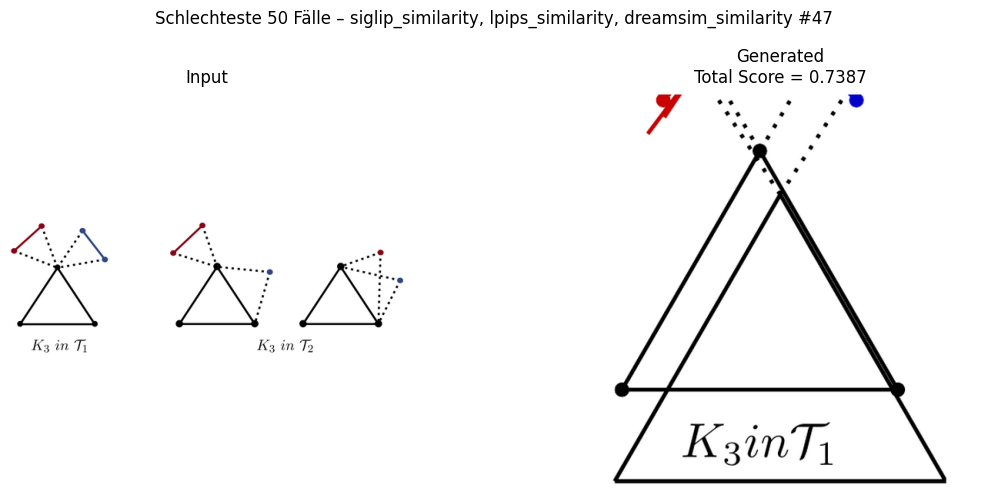

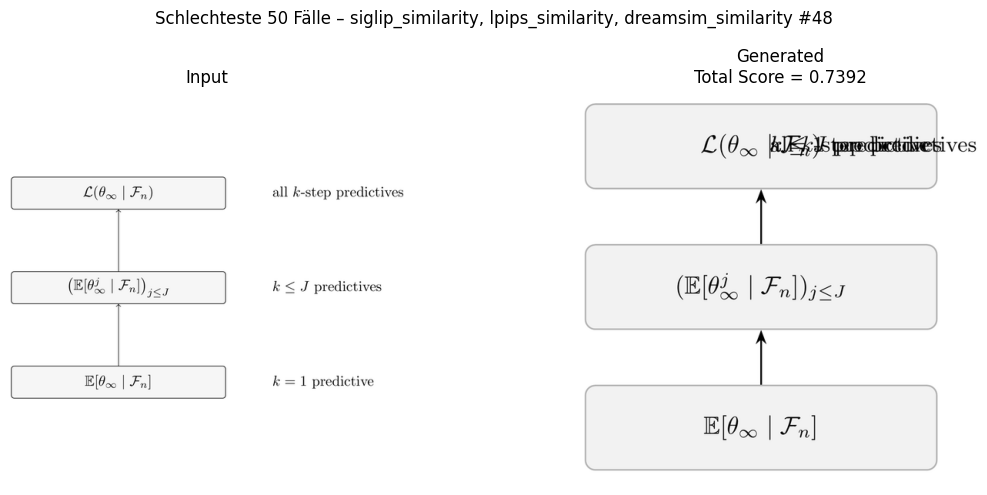

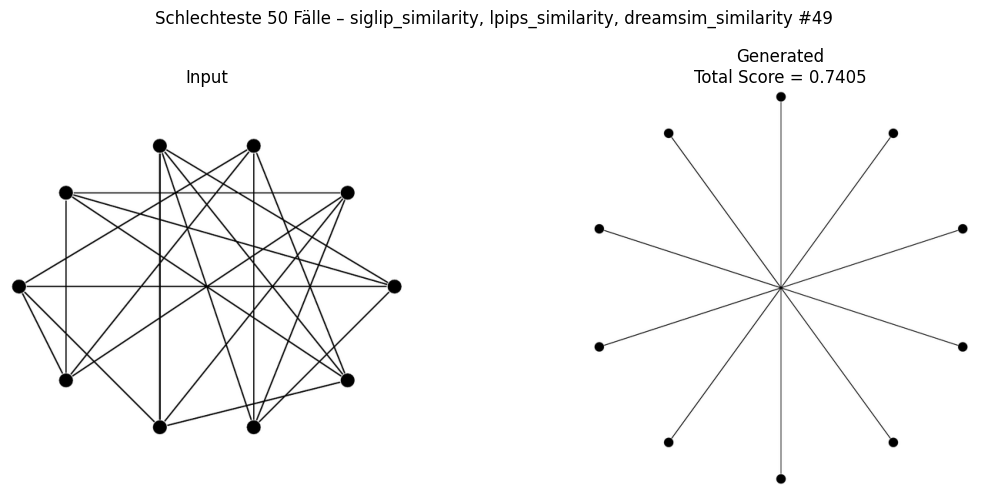

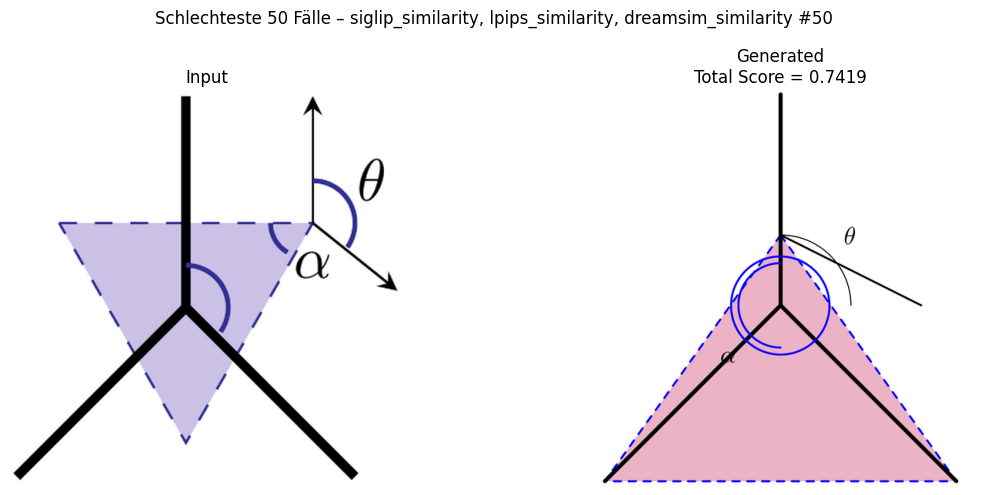

In [35]:
# Schlechteste Fälle: vorhandenes generiertes Bild und Input-Bild anzeigen
show_cases(worst, f"Schlechteste {len(worst)} Fälle – " + ", ".join(METRICS))